<a href="https://colab.research.google.com/github/ismailuddinraihan-eng/Problem-Set-2/blob/main/Problem_Set_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Set-2

Unzipping dataset...
Dataset Loaded Successfully!
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entri

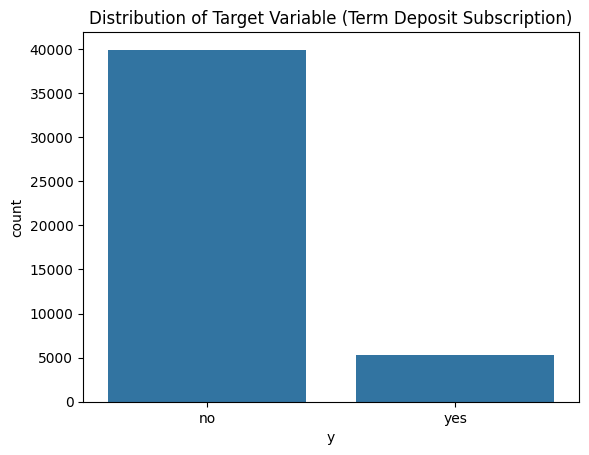


--- Model Evaluation ---
Accuracy Score: 0.89

Confusion Matrix:


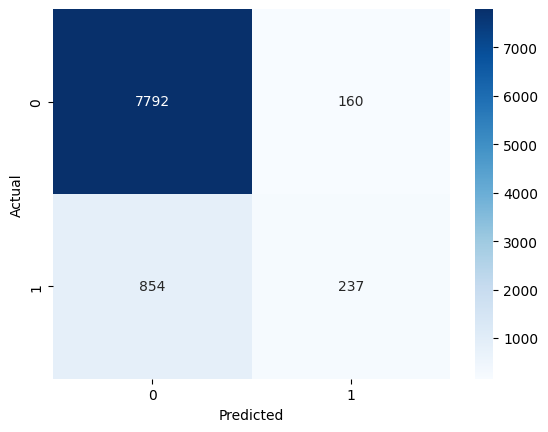


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.60      0.22      0.32      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.86      0.89      0.86      9043



In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 2. Download and Unzip the dataset
# We use the file ID from your provided link
file_id = '18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ'
url = f'https://drive.google.com/uc?id={file_id}'

import os
import requests
import zipfile

# Download the file
print("Downloading dataset...")
response = requests.get(url, stream=True)
with open("bank_data.zip", "wb") as f:
    f.write(response.content)

# Unzip the file
print("Unzipping dataset...")
with zipfile.ZipFile("bank_data.zip", "r") as zip_ref:
    zip_ref.extractall("bank_content")

# Locate the CSV file based on your description
# Path: bank_content/bank-data/bank-full.csv
csv_path = 'bank_content/bank-data/bank-full.csv'

# 3. Load the Dataset
# Note: This specific dataset often uses ';' as a separator
df = pd.read_csv(csv_path, sep=';')
print("Dataset Loaded Successfully!")
print(df.head())

# 4. Exploratory Data Analysis (EDA)
print(df.info())
sns.countplot(x='y', data=df)
plt.title('Distribution of Target Variable (Term Deposit Subscription)')
plt.show()

# 5. Data Preprocessing
# Encoding categorical variables
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Splitting features and target
X = df.drop('y', axis=1)
y = df['y']

# Splitting into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Important for Logistic Regression convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Build and Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 7. Model Evaluation
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))